### Importing libraries needed


In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Phase 1 : Cleaning and Ingestion

### Reading the dataset and exploring data

In [5]:
df=pd.read_csv('raw_df.csv')

In [6]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Ticker'],
      dtype='str')


In [7]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2016-04-28 00:00:00-04:00,3.69,3.80,3.60,3.61,20230000,0.0,0.0,AMD
1,2016-04-29 00:00:00-04:00,3.69,3.69,3.45,3.55,17717800,0.0,0.0,AMD
2,2016-05-02 00:00:00-04:00,3.58,3.75,3.57,3.74,16972800,0.0,0.0,AMD
3,2016-05-03 00:00:00-04:00,3.70,3.71,3.58,3.60,13784800,0.0,0.0,AMD
4,2016-05-04 00:00:00-04:00,3.54,3.67,3.54,3.60,8688500,0.0,0.0,AMD


In [8]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,12565.000000,12565.000000,12565.000000,12565.000000,1.256500e+04,12565.000000,12565.000000
mean,112.177503,113.544622,110.743258,112.185470,1.172467e+08,0.003535,0.002706
std,108.051768,109.100393,106.901412,108.043816,2.056580e+08,0.047992,0.202639
min,0.854601,0.860966,0.842116,0.850929,1.499700e+06,0.000000,0.000000
25%,32.510735,32.821238,32.239202,32.518959,1.918140e+07,0.000000,0.000000
50%,84.300003,85.769997,83.094985,84.490906,3.274400e+07,0.000000,0.000000
75%,150.120687,152.820007,148.056501,150.263748,7.985370e+07,0.000000,0.000000
max,552.023241,552.242002,538.530591,539.825195,3.692928e+09,1.345000,20.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12565 entries, 0 to 12564
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          12565 non-null  str    
 1   Open          12565 non-null  float64
 2   High          12565 non-null  float64
 3   Low           12565 non-null  float64
 4   Close         12565 non-null  float64
 5   Volume        12565 non-null  int64  
 6   Dividends     12565 non-null  float64
 7   Stock Splits  12565 non-null  float64
 8   Ticker        12565 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 1.2 MB


### Verifying data types

In [10]:
# 1. Convert to datetime, forcing all mixed timezones to align to UTC first
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# 2. Strip the timezone information completely so it's a standard, naive date
df['Date'] = df['Date'].dt.tz_localize(None)

# 3. Normalize to remove the hours/minutes/seconds, leaving just YYYY-MM-DD
df['Date'] = df['Date'].dt.normalize()

df['Date'].head()

0   2016-04-28
1   2016-04-29
2   2016-05-02
3   2016-05-03
4   2016-05-04
Name: Date, dtype: datetime64[us]

### Droping uneeded columns

In [11]:
df = df.drop('Stock Splits', axis=1, errors='ignore')
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Ticker'],
      dtype='str')


### Checking for errors

In [12]:
# 1. Check for High price being lower than Low price
# We filter the dataframe to only show rows where this impossible condition is True
bad_prices = df[df['High'] < df['Low']]

print(f"Number of rows with High < Low = {len(bad_prices)}")
if len(bad_prices) > 0:
    display(bad_prices.head()) # Take a look at the bad data

# 2. Check for negative or zero trading volume
negative_volume = df[df['Volume'] < 0]

print(f"Number of rows with negative volume = {len(negative_volume)}")
if len(negative_volume) > 0:
    display(negative_volume.head())

Number of rows with High < Low = 0
Number of rows with negative volume = 0


## Phase 2 : structuring and feature engineering

In [13]:
#Sort and create the groupby object

df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)
ticker_group = df.groupby('Ticker')

ticker_group.get_group("AMD")[ticker_group.get_group("AMD")['Date']=='2016-04-28'].head()

,Date,Open,High,Low,Close,Volume,Dividends,Ticker
0,2016-04-28,3.69,3.8,3.6,3.61,20230000,0.0,AMD


In [14]:
#Time context

df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month

df[['month','day_of_week']].head()

,month,day_of_week
0,4,3
1,4,4
2,5,0
3,5,1
4,5,2


In [15]:
#The Dividend Event Flag
df['is_dividend_day'] = (df['Dividends'] > 0).astype(int)

#total number of dividend drop occurred.
df['Date'][df['is_dividend_day']==1].count()

np.int64(119)

In [19]:
#Daily Return
df['daily_return'] = ticker_group['Close'].pct_change()
df['daily_return']

0             NaN
1       -0.016620
2        0.053521
3       -0.037433
4        0.000000
           ...   
12560    0.005024
12561    0.052597
12562   -0.012337
12563    0.051743
12564    0.006262
Name: daily_return, Length: 12565, dtype: float64

### Rolling Indicators

In [20]:
# --- 1. Moving Averages (Trend & Momentum) ---
# WHY: Smooths out daily market noise. Comparing the fast 1-month trend (20) 
# to the slow 1-quarter trend (50) allows the model to detect major momentum shifts.
df['sma_20'] = ticker_group['Close'].transform(lambda x: x.rolling(window=20).mean())
df['sma_50'] = ticker_group['Close'].transform(lambda x: x.rolling(window=50).mean())

# --- 2. Volatility (Risk Assessment) ---
# WHY: Teaches the model to quantify risk. High values warn the model that 
# the stock is behaving erratically, allowing us to find risk-adjusted winners.
df['std_dev_20'] = ticker_group['Close'].transform(lambda x: x.rolling(window=20).std())

# --- 3. Bollinger Bands (Hype & Fear Detection) ---
# WHY: Creates mathematical boundaries (2 standard deviations) for normal price action. 
# Helps the model predict reversals when a stock becomes extremely overbought or oversold.
df['bollinger_upper'] = df['sma_20'] + (df['std_dev_20'] * 2)
df['bollinger_lower'] = df['sma_20'] - (df['std_dev_20'] * 2)

### Defining the Target & Cleanup

In [21]:
# 1. Shift the close price for the target
df['tomorrow_close'] = ticker_group['Close'].shift(-1)

# 2. Binary target (1 if tomorrow is higher than today)
df['target'] = (df['tomorrow_close'] > df['Close']).astype(int)

# 3. Clean up the NaN values generated by the shift() and rolling() functions
df = df.dropna().reset_index(drop=True)

## Phase 3: Analytics & The Investment Decision

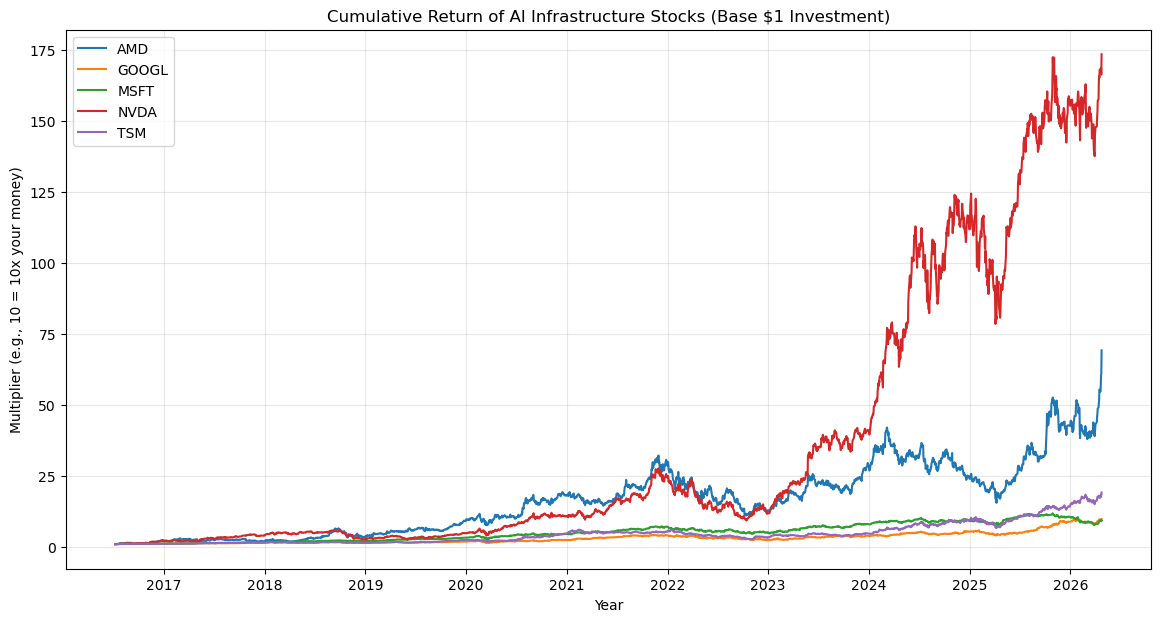

In [22]:
# 1. Calculate the cumulative return for each ticker
# We group by ticker so the math doesn't bleed across companies
df['cum_return'] = df.groupby('Ticker')['daily_return'].transform(lambda x: (1 + x).cumprod())

# 2. Plot the results visually
plt.figure(figsize=(14, 7))

# Loop through each unique ticker and plot its cumulative return line
for ticker in df['Ticker'].unique():
    ticker_data = df[df['Ticker'] == ticker]
    plt.plot(ticker_data['Date'], ticker_data['cum_return'], label=ticker)

plt.title('Cumulative Return of AI Infrastructure Stocks (Base $1 Investment)')
plt.xlabel('Year')
plt.ylabel('Multiplier (e.g., 10 = 10x your money)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Feature Correlation

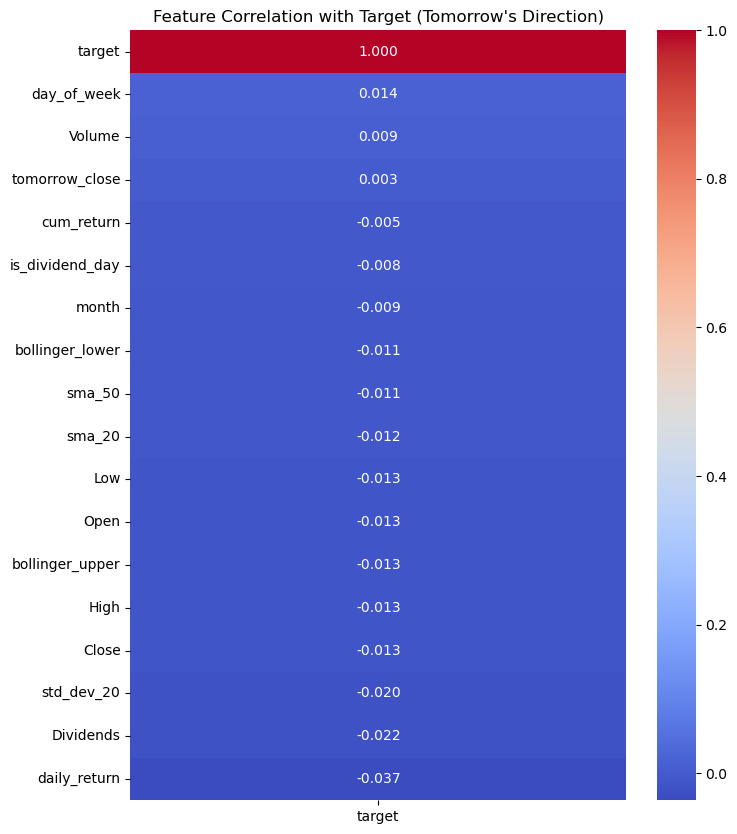

In [23]:
# 1. Select ONLY the numerical columns (correlation math breaks on text columns like 'Ticker')
# We drop 'Date' and 'Ticker' for this calculation
numeric_df = df.drop(columns=['Date', 'Ticker'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. We really only care about how everything correlates to the 'target'
target_correlation = corr_matrix[['target']].sort_values(by='target', ascending=False)

# 4. Plot a heatmap to visualize the strongest signals
plt.figure(figsize=(8, 10))
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Feature Correlation with Target (Tomorrow's Direction)")
plt.show()

In [24]:
# --- 1. The SMA Ratio (Momentum Indicator) ---
# Formula: Fast Average / Slow Average
df['sma_ratio'] = df['sma_20'] / df['sma_50']

# --- 2. Bollinger Band Position (Rubber Band Stretch Indicator) ---
# Formula: (Current Price - Lower Band) / (Upper Band - Lower Band)
df['bb_position'] = (df['Close'] - df['bollinger_lower']) / (df['bollinger_upper'] - df['bollinger_lower'])

# --- 3. Clean up ---
# We use dropna() again just in case our new math created any weird infinity/NaN values
df = df.dropna().reset_index(drop=True)

# --- 4. Re-run the Target Correlation ---
# Let's see if our new custom features score higher than the raw numbers!
numeric_df = df.drop(columns=['Date', 'Ticker'])
new_correlations = numeric_df.corr()[['target']].sort_values(by='target', ascending=False)

print("--- Updated Target Correlations ---")
print(new_correlations)

--- Updated Target Correlations ---
                   target
target           1.000000
day_of_week      0.013842
Volume           0.009404
tomorrow_close   0.003198
cum_return      -0.005306
is_dividend_day -0.007929
month           -0.009292
bollinger_lower -0.010966
sma_50          -0.011095
sma_20          -0.011916
Low             -0.012624
Open            -0.012701
bollinger_upper -0.012740
High            -0.013027
Close           -0.013169
sma_ratio       -0.018147
std_dev_20      -0.020469
bb_position     -0.020669
Dividends       -0.022163
daily_return    -0.036565


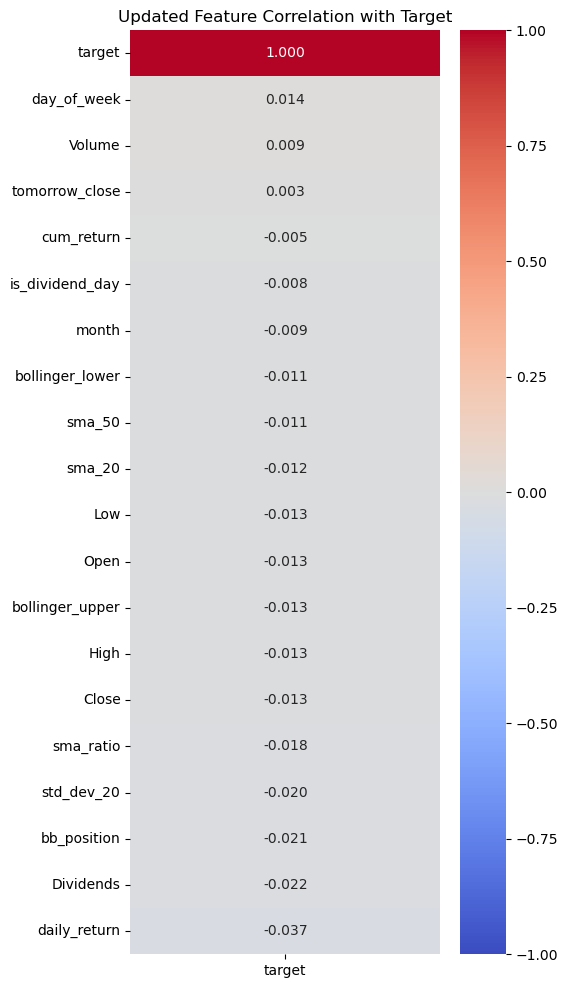

In [73]:
# 1. Ensure we are only looking at the numerical data
numeric_df = df.drop(columns=['Date', 'Ticker'])

# 2. Calculate the updated correlation matrix
new_corr_matrix = numeric_df.corr()

# 3. Isolate just the 'target' column and sort it from highest to lowest
target_correlation = new_corr_matrix[['target']].sort_values(by='target', ascending=False)

# 4. Set up the canvas (narrow and tall is best for a single column)
plt.figure(figsize=(5, 12))

# 5. Generate the heatmap! 
# (vmin=-1 and vmax=1 ensure the color scale stays anchored, 
# preventing minor noise from looking bright red)
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)

plt.title("Updated Feature Correlation with Target")
plt.show()

In [25]:
# --- 1. MACRO TRENDS & SEASONALITY ---

# Seasonality: What time of year are we in?
df['year'] = df['Date'].dt.year
df['quarter'] = df['Date'].dt.quarter

# Macro Trend: The 200-day moving average (roughly 1 trading year)
df['sma_200'] = ticker_group['Close'].transform(lambda x: x.rolling(window=200).mean())

# Macro Stretch: How far is today's price from the 1-year average? 
# (> 1.0 means massive long-term uptrend, < 1.0 means long-term crash)
df['macro_trend_distance'] = df['Close'] / df['sma_200']


# --- 2. RISK & VIOLENT MOVES  ---

# Daily Swing: The percentage difference between the High and Low of the day
df['daily_swing_percent'] = (df['High'] - df['Low']) / df['Close']

# True Volatility: The standard deviation of the daily returns over a month
df['historical_volatility'] = ticker_group['daily_return'].transform(lambda x: x.rolling(window=20).std())


# --- 3. WEEKLY & MONTHLY RETURNS  ---

# pct_change(5) compares today's price to the price exactly 5 days ago
df['weekly_return'] = ticker_group['Close'].pct_change(periods=5)

# pct_change(21) compares today's price to the price exactly 21 days ago
df['monthly_return'] = ticker_group['Close'].pct_change(periods=21)


# --- 4. THE CLEANUP ---
# WARNING: Because we just calculated a 200-day moving average, 
# Pandas will generate NaNs for the first 199 days of every company!
# We MUST drop them before giving this to the AI.
df = df.dropna().reset_index(drop=True)

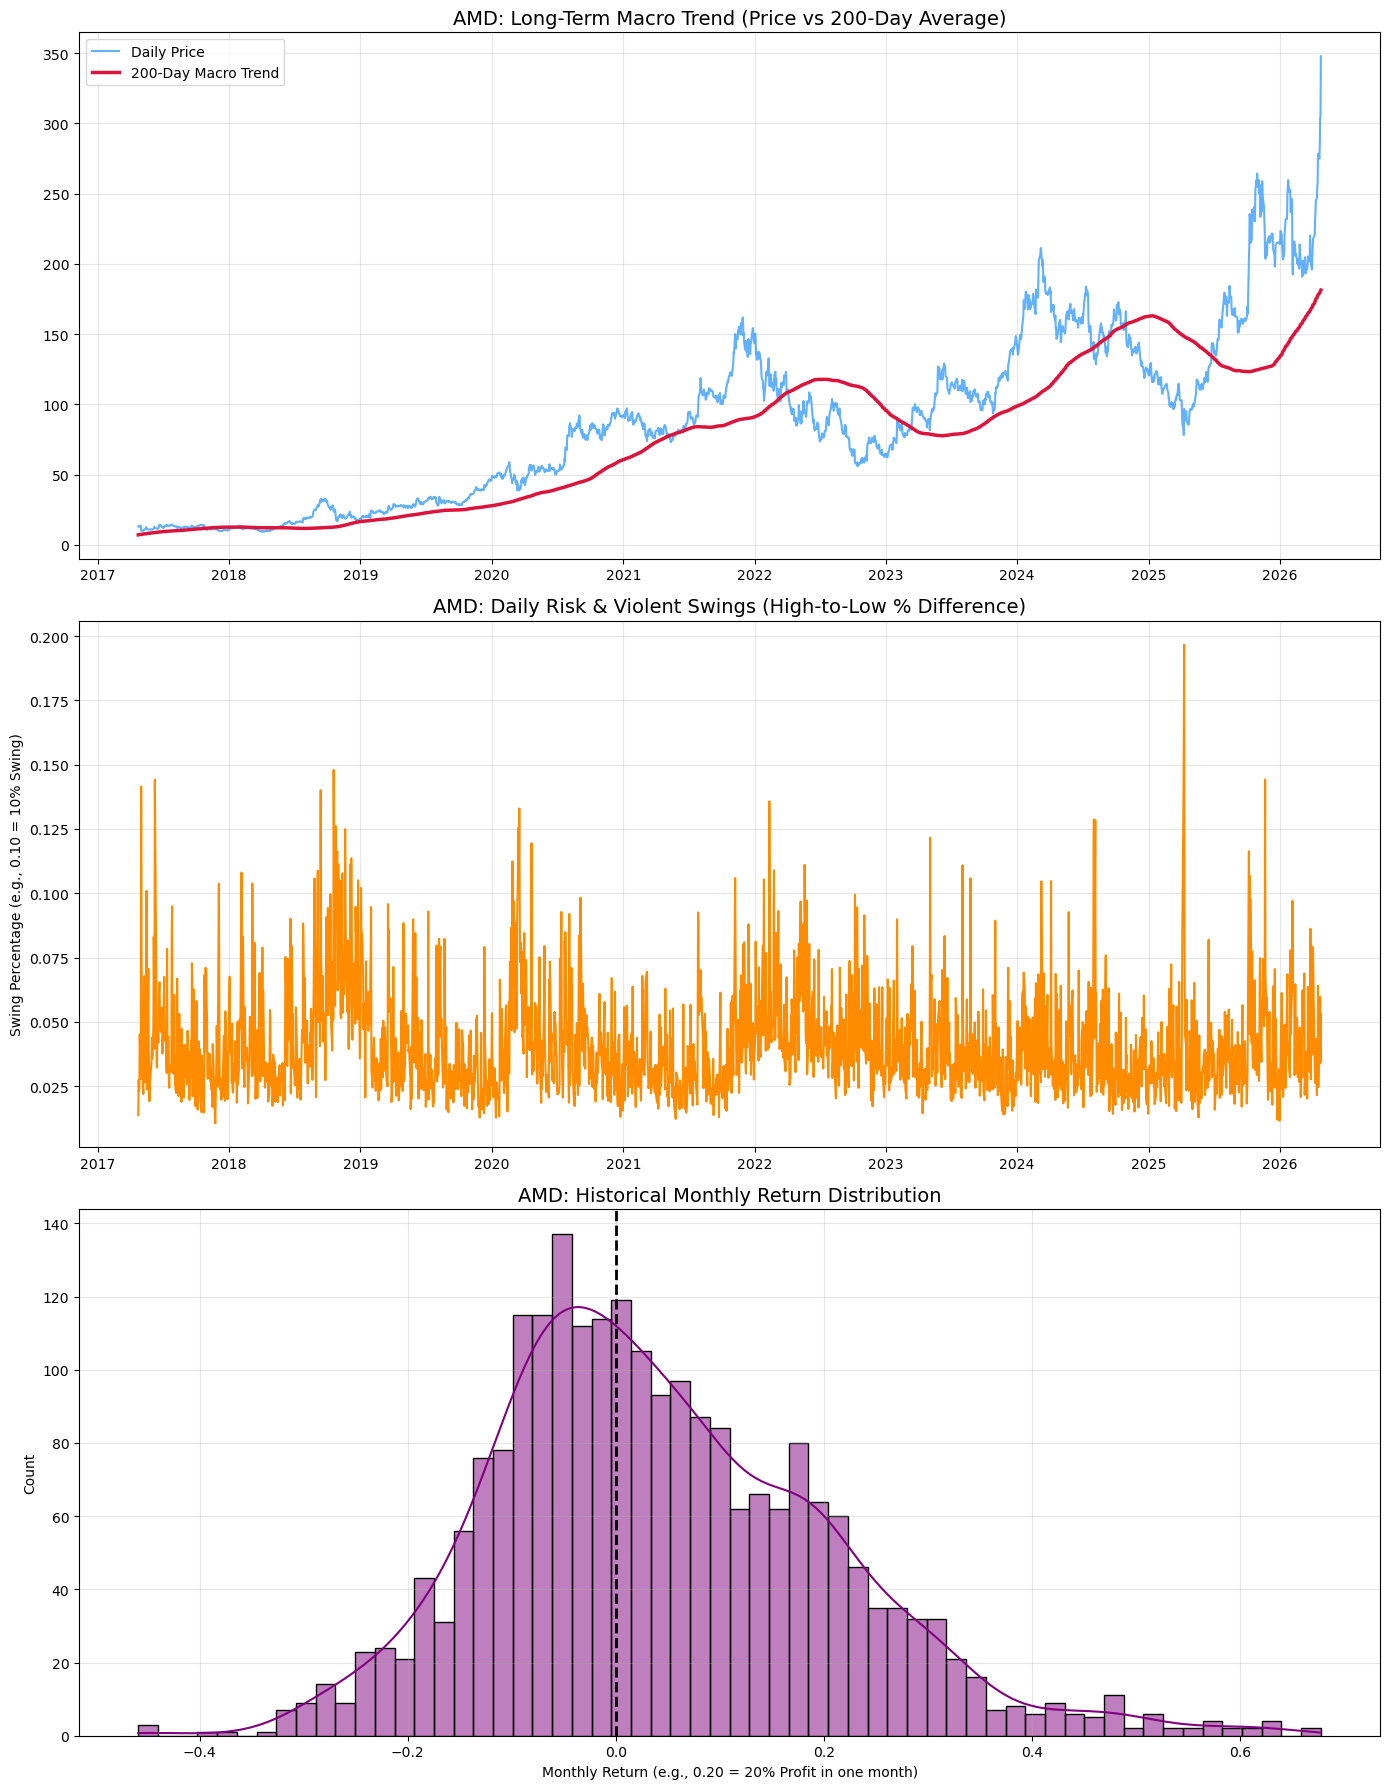

In [ ]:
# 1. Pick a single stock to analyze (You can change this to 'NVDA', 'MSFT', etc.)
target_stock = "AMD"
stock_data = df[df['Ticker'] == target_stock]

# 2. Set up a massive canvas with 3 rows and 1 column
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# ---------------------------------------------------------
# CHART 1: Macro Trend 
# ---------------------------------------------------------
# We plot the daily price against the 200-day moving average.
# When the blue line stretches far above the red line, the stock is historically expensive.
axes[0].plot(stock_data['Date'], stock_data['Close'], label='Daily Price', color='dodgerblue', alpha=0.7)
axes[0].plot(stock_data['Date'], stock_data['sma_200'], label='200-Day Macro Trend', color='crimson', linewidth=2.5)
axes[0].set_title(f"{target_stock}: Long-Term Macro Trend (Price vs 200-Day Average)", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# CHART 2: Risk & Violent Swings 
# ---------------------------------------------------------
# We plot the 'daily_swing_percent' to see exactly when the stock was acting violently.
# Huge spikes mean the stock was having massive, aggressive swings in a single day.
axes[1].plot(stock_data['Date'], stock_data['daily_swing_percent'], color='darkorange', linewidth=1.5)
axes[1].set_title(f"{target_stock}: Daily Risk & Violent Swings (High-to-Low % Difference)", fontsize=14)
axes[1].set_ylabel("Swing Percentage (e.g., 0.10 = 10% Swing)")
axes[1].grid(True, alpha=0.3)

# ---------------------------------------------------------
# CHART 3: Monthly Returns Distribution
# ---------------------------------------------------------
# A histogram showing how often this stock has massive monthly gains vs massive monthly crashes.
# If the bell curve is wide, it's a risky stock. If it's narrow, it's a safe/boring stock.
sns.histplot(stock_data['monthly_return'], bins=60, kde=True, ax=axes[2], color='purple')
axes[2].set_title(f"{target_stock}: Historical Monthly Return Distribution", fontsize=14)
axes[2].set_xlabel("Monthly Return (e.g., 0.20 = 20% Profit in one month)")
axes[2].axvline(0, color='black', linestyle='--', linewidth=2) # Draws a line at 0% (Breakeven)
axes[2].grid(True, alpha=0.3)

# Make it look clean and show the dashboard!
plt.tight_layout()
plt.show()

In [27]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Ticker',
       'day_of_week', 'month', 'is_dividend_day', 'daily_return', 'sma_20',
       'sma_50', 'std_dev_20', 'bollinger_upper', 'bollinger_lower',
       'tomorrow_close', 'target', 'cum_return', 'sma_ratio', 'bb_position',
       'year', 'quarter', 'sma_200', 'macro_trend_distance',
       'daily_swing_percent', 'historical_volatility', 'weekly_return',
       'monthly_return'],
      dtype='str')